In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from skimage.measure import regionprops
from scipy.ndimage import label
import nibabel as nib


def collect_instance_metrics_2d(base_path, task_name, splits=['train', 'val', 'test']):
    rows = []

    for split in splits:
        # Path: Basepath/(split)/labels/(task)/
        label_dir = os.path.join(base_path, split, 'labels', task_name)

        if not os.path.exists(label_dir):
            print(f"Skipping {split}: Directory not found.")
            continue

        label_files = [f for f in os.listdir(label_dir) if f.endswith('.png')]

        for filename in label_files:
            mask_path = os.path.join(label_dir, filename)
            mask = np.array(Image.open(mask_path))

            labeled_mask, _ = label(mask > 0, np.ones((3, 3), dtype=np.int32))

            props = regionprops(labeled_mask)

            if not props:
                continue

            all_areas = np.array([p.area for p in props])

            rows.append({
                'split': split,
                'class': task_name,
                'filename': filename,
                'n_instances': len(all_areas),
                'all_areas': all_areas,
                # Using 'mm2' label per your template
                'max_area_mm2': np.max(all_areas),
                'total_area_mm2': np.sum(all_areas)
            })

    return pd.DataFrame(rows)


def collect_instance_metrics_3d(label_dir, task_name):
    """
    Analyzes 3D NIfTI labels for instance metrics.
    Assumes binary masks (0 = background, >0 = instances).
    """
    rows = []

    label_files = [f for f in os.listdir(
        label_dir) if f.endswith(('.nii', '.nii.gz'))]

    if not label_files:
        print(f"No NIfTI files found in {label_dir}")
        return pd.DataFrame()

    for filename in label_files:
        file_path = os.path.join(label_dir, filename)

        img = nib.load(file_path)
        data = img.get_fdata()

        labeled_vol, _ = label(data > 0, np.ones((3, 3, 3), dtype=np.int32))
        props = regionprops(labeled_vol)

        if not props:
            continue

        all_volumes = np.array([p.area for p in props])

        rows.append({
            'split': 'all',
            'class': task_name,
            'filename': filename,
            'n_instances': len(all_volumes),
            'all_areas': all_volumes,
            'max_area_mm2': np.max(all_volumes),
            'total_area_mm2': np.sum(all_volumes)
        })

    return pd.DataFrame(rows)

In [8]:
LABEL_DIR = "/home/student/sebastian_ma/Learning-to-Look-Closer/data/nnUNet_raw/Dataset601_WMH/labelsTr"
TASK = "White Matter Hyperintensities"

df_metrics_3d = collect_instance_metrics_3d(LABEL_DIR, TASK)
df_metrics_3d.head()

,split,class,filename,n_instances,all_areas,max_area_mm2,total_area_mm2
0,all,White Matter Hyperintensities,WMH_53.nii.gz,46,"[3.0, 2.0, 4.0, 11.0, 2.0, 2.0, 11.0, 1.0, 4.0...",48.0,381.0
1,all,White Matter Hyperintensities,WMH_137.nii.gz,152,"[2.0, 6.0, 44.0, 10.0, 6.0, 34.0, 8.0, 18.0, 1...",348.0,2552.0
2,all,White Matter Hyperintensities,WMH_25.nii.gz,38,"[4.0, 5150.0, 9.0, 4.0, 3.0, 2.0, 4.0, 13.0, 6...",5150.0,8743.0
3,all,White Matter Hyperintensities,WMH_4.nii.gz,62,"[27.0, 11.0, 7.0, 2.0, 5426.0, 11.0, 7.0, 1.0,...",5426.0,11290.0
4,all,White Matter Hyperintensities,WMH_2.nii.gz,140,"[5.0, 20.0, 3.0, 1.0, 3.0, 10.0, 15.0, 13.0, 4...",4576.0,11859.0


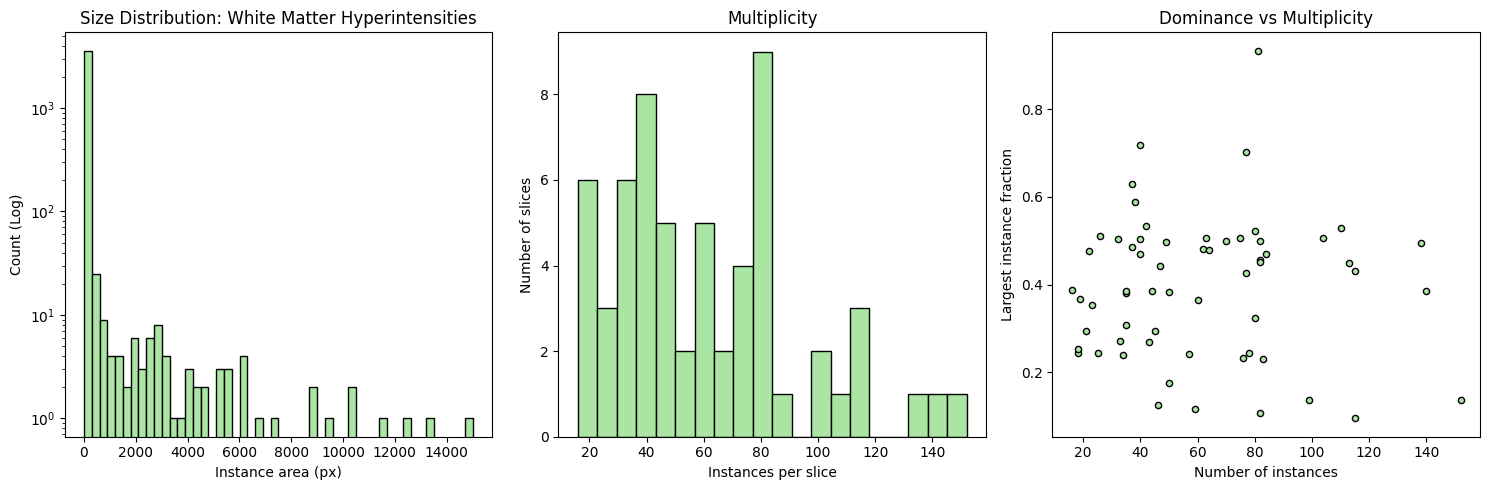

In [ ]:
if not df_metrics_3d.empty:
    target_class = TASK
    class_df = df_metrics_3d[df_metrics_3d['class'] == target_class]
    all_areas = np.concatenate(class_df['all_areas'].values)
    largest_fractions = class_df["max_area_mm2"] / class_df["total_area_mm2"]

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.hist(all_areas, bins=50, color='#aae5a4', edgecolor='black', log=True)
    plt.xlabel("Instance area (px)")
    plt.ylabel("Count (Log)")
    plt.title(f"Size Distribution: {target_class}")

    plt.subplot(1, 3, 2)
    plt.hist(class_df["n_instances"], bins=20,
             color='#aae5a4', edgecolor='black')
    plt.xlabel("Instances per slice")
    plt.ylabel("Number of slices")
    plt.title("Multiplicity")

    plt.subplot(1, 3, 3)
    plt.scatter(class_df["n_instances"], largest_fractions,
                color='#aae5a4', edgecolor='black', alpha=1, s=20)
    plt.xlabel("Number of instances")
    plt.ylabel("Largest instance fraction")
    plt.title("Dominance vs Multiplicity")

    plt.tight_layout()
    plt.show()
else:
    print("No data found. Check your paths and file extensions.")